# Exploratory Data Analysis (EDA)

1. Import Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

2. Load DataSet

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


3. Create a Copy of the Dataset

In [3]:
eda_df = df.copy()

In [4]:
eda_df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [6]:
eda_df["Attrition"].value_counts(normalize= True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

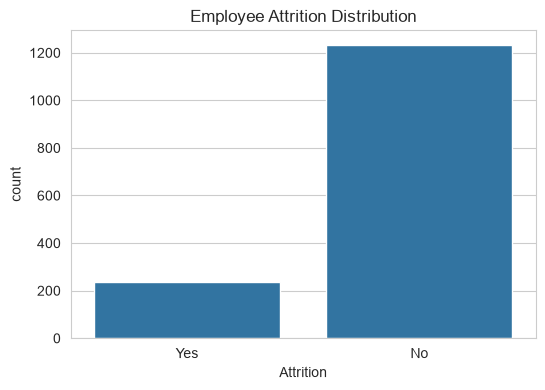

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(data = eda_df, x = "Attrition")
plt.title("Employee Attrition Distribution")
plt.show()

### Observation

1. The "No" class is much larger than the "Yes" class.
2. The dataset is imbalanced because most employees did not leave the company.
3. Approximately 16% of employees left, while around 84% stayed. 

4. Numerical Features Distribution

In [7]:
numerical_columns = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

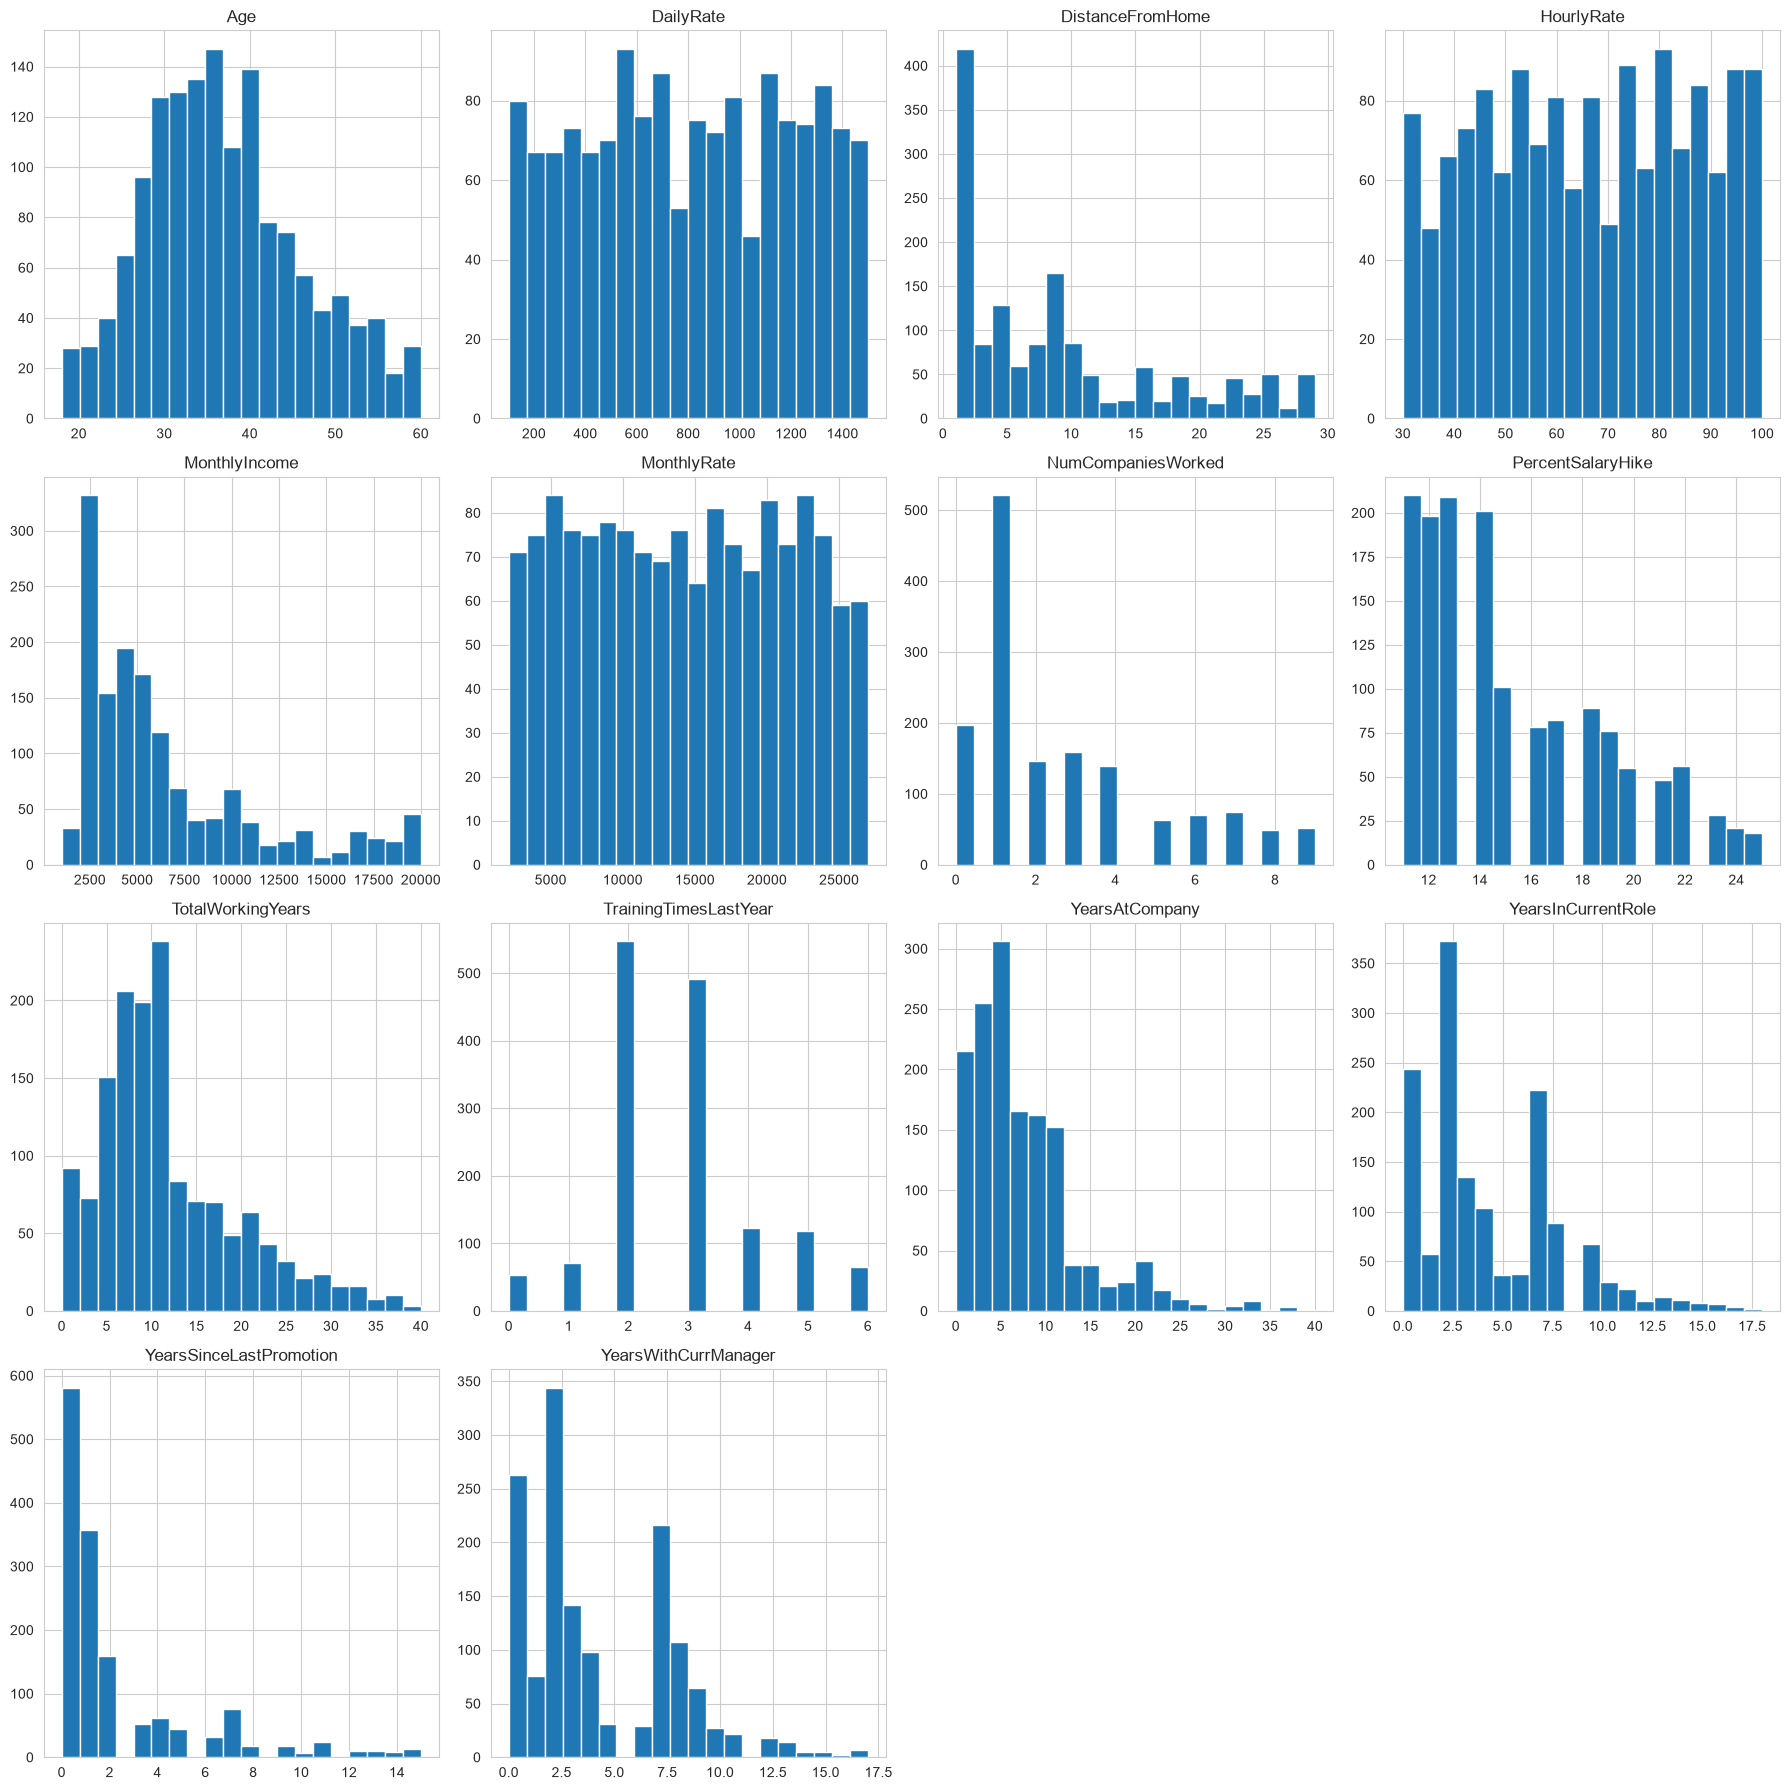

In [8]:
eda_df[numerical_columns].hist(
    figsize=(18,18),
    bins=20
)
plt.tight_layout()
plt.show()

### Key Observation

1. Age is approximately normally distributed, with most employees between 30–40 years.
2. MonthlyIncome, DistanceFromHome, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, and YearsWithCurrManager are right-skewed, indicating that most employees have lower values while a few have much higher values.
3. DailyRate, HourlyRate, and MonthlyRate appear to have a nearly uniform distribution.
4. TrainingTimesLastYear is a discrete numerical feature, as it contains only a few integer values (0–6).
5. Most experience-related features (TotalWorkingYears, YearsAtCompany, etc.) show that the majority of employees have relatively fewer years of experience, with only a small number having very high experience.
6. No obvious data quality issues (such as impossible values) are visible from the histograms, although some features contain naturally occurring extreme values.

5. Categorical Features

In [10]:
categorical_columns = eda_df.select_dtypes(include="object").columns
categorical_columns

/var/folders/83/lyk88fr96bq5vfw5v_m3j0n40000gn/T/ipykernel_30211/4096759956.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = eda_df.select_dtypes(include="object").columns


Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

In [12]:
for column in categorical_columns:
    print("=" * 50)
    print(eda_df[column].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Gender
Male      882
Female    588
Name: count, dtype: int64
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64
Over18
Y    1470
Name: count,

### Observations

1. The target variable (Attrition) is imbalanced, with significantly more employees staying than leaving.
2. Most employees travel Rarely for business.
3. The majority of employees belong to the Research & Development department.
4. Life Sciences and Medical are the most common education fields.
5. The most common job role is Sales Executive.
6. The Over18 column contains only one value (`Y`), so it does not provide useful information and can be dropped.

6. Attrition vs Gender

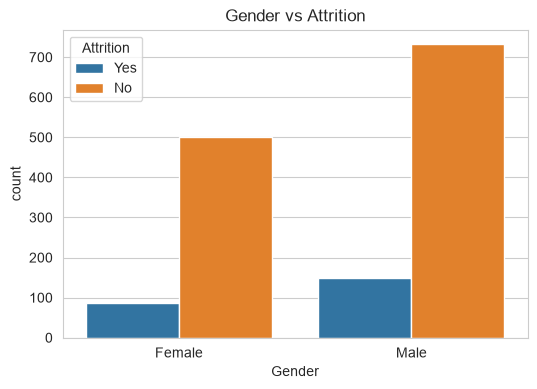

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data = eda_df,
    x = "Gender",
    hue = "Attrition"
)
plt.title("Gender vs Attrition")
plt.show()

### Observation

1. The company has more male employees than female employees.
2. For both genders, the number of employees who stayed is much higher than those who left.
3.  Male employees have a higher attrition count than female employees, but they also represent a larger portion of the workforce.
4.  Based on this count plot alone, we cannot conclude that gender significantly affects attrition. A percentage-based comparison would provide a more accurate analysis.

7. Attrition vs Department

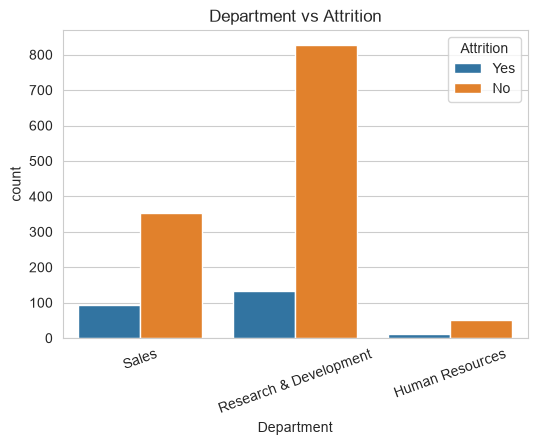

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    data = eda_df,
    x = "Department",
    hue = "Attrition"
)

plt.xticks(rotation=20)
plt.title("Department vs Attrition")
plt.show()

### Observation

1. Research & Development has the highest number of employees and the highest attrition count.
2. In every department, employees who stayed are significantly more than those who left.
3. A higher attrition count does not necessarily indicate a higher attrition rate because departments have different employee sizes.

8. Attrition vs Job Role

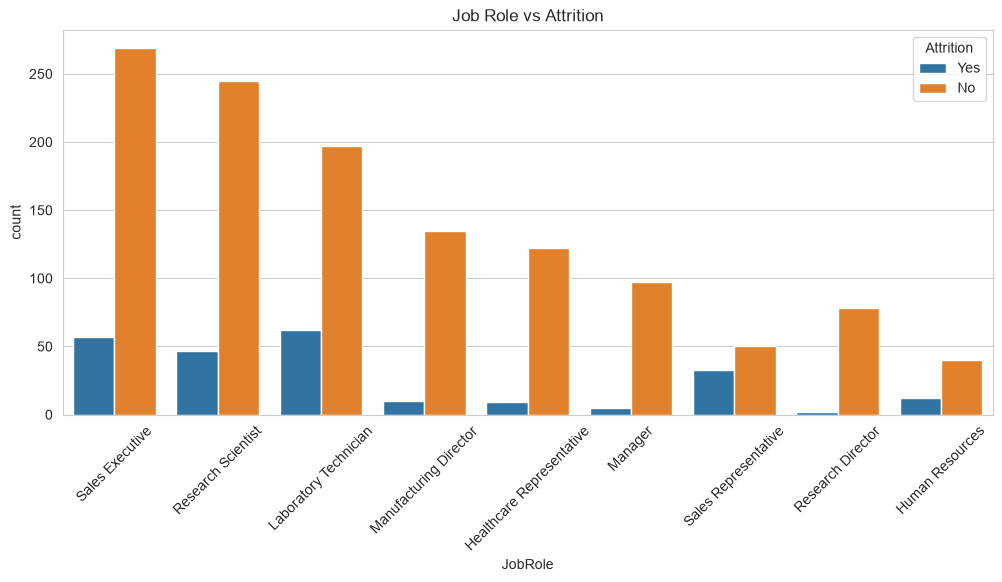

In [20]:
plt.figure(figsize=(12,5))

sns.countplot(
    data = eda_df,
    x = 'JobRole',
    hue = "Attrition"
)
plt.xticks(rotation=45)
plt.title("Job Role vs Attrition")
plt.show()

### Observation

1. Sales Executives and Laboratory Technicians have the highest attrition counts.
2. Research Scientists also show noticeable attrition.
3. Managers and Research Directors have the lowest attrition.
4. In every job role, more employees stayed than left.
5. Attrition count alone is not enough; attrition rate should be calculated for a fair comparison.

9. Attrition vs Overtime

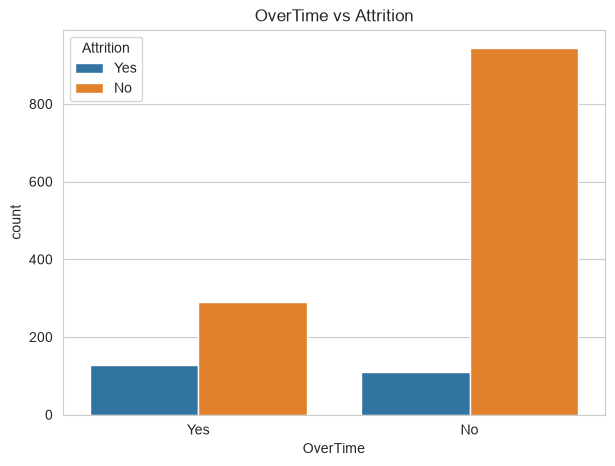

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(
    data = eda_df,
    x = "OverTime",
    hue = "Attrition"
)
plt.title("OverTime vs Attrition")
plt.show()

### Key Observation

1. Most employees do not work overtime.
2. Employees working overtime show relatively higher attrition.
3. Overtime may be a factor contributing to employee attrition.

10. Monthly Income vs Attrition

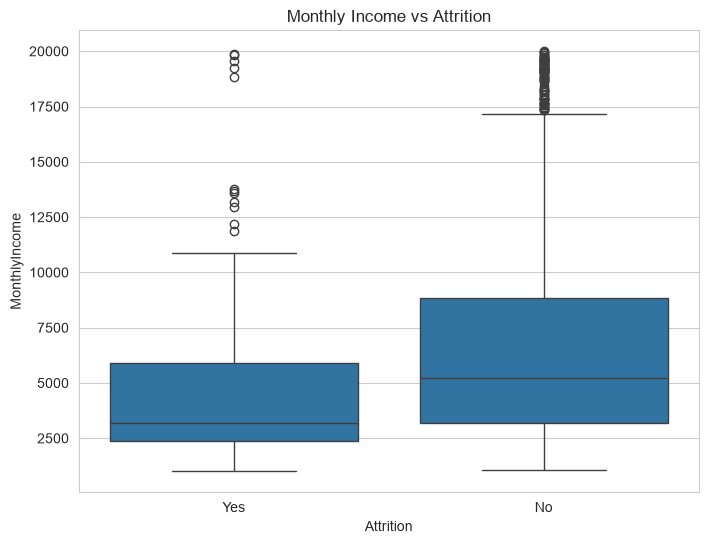

In [22]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data = eda_df,
    x = "Attrition",
    y = "MonthlyIncome"
)
plt.title("Monthly Income vs Attrition")
plt.show()

### Observation:

1. Employees who left the company (`Attrition = Yes`) have a lower median monthly income than those who stayed.
2. Both groups contain several high-income outliers.
3. Employees who stayed show a wider range of monthly incomes.
4. Lower monthly income appears to be associated with higher attrition, although salary alone does not fully explain employee turnover.

11. Age vs Attrition

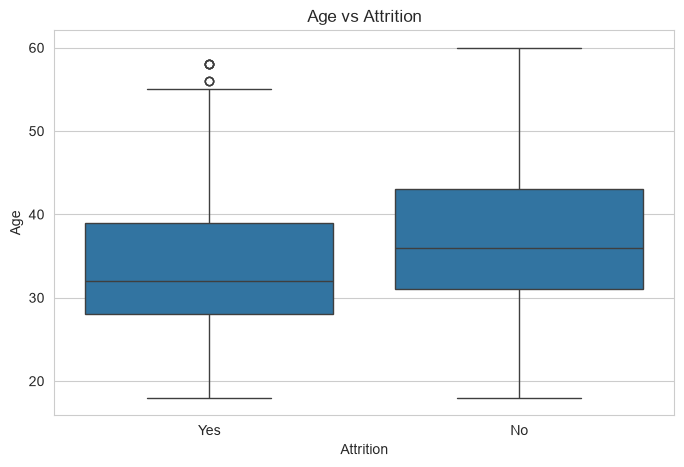

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data = eda_df,
    x = "Attrition",
    y = "Age"
)
plt.title("Age vs Attrition")
plt.show()

### Observation:
1. Employees who left (`Attrition = Yes`) have a lower median age than those who stayed.
2. A few older employees who left appear as outliers.
3. Age appears to have some relationship with attrition, but it is not the only factor influencing employee turnover.

12. Correlation Matrix

In [24]:
numeric_df = eda_df.select_dtypes(include=["number"])
corr = numeric_df.corr()

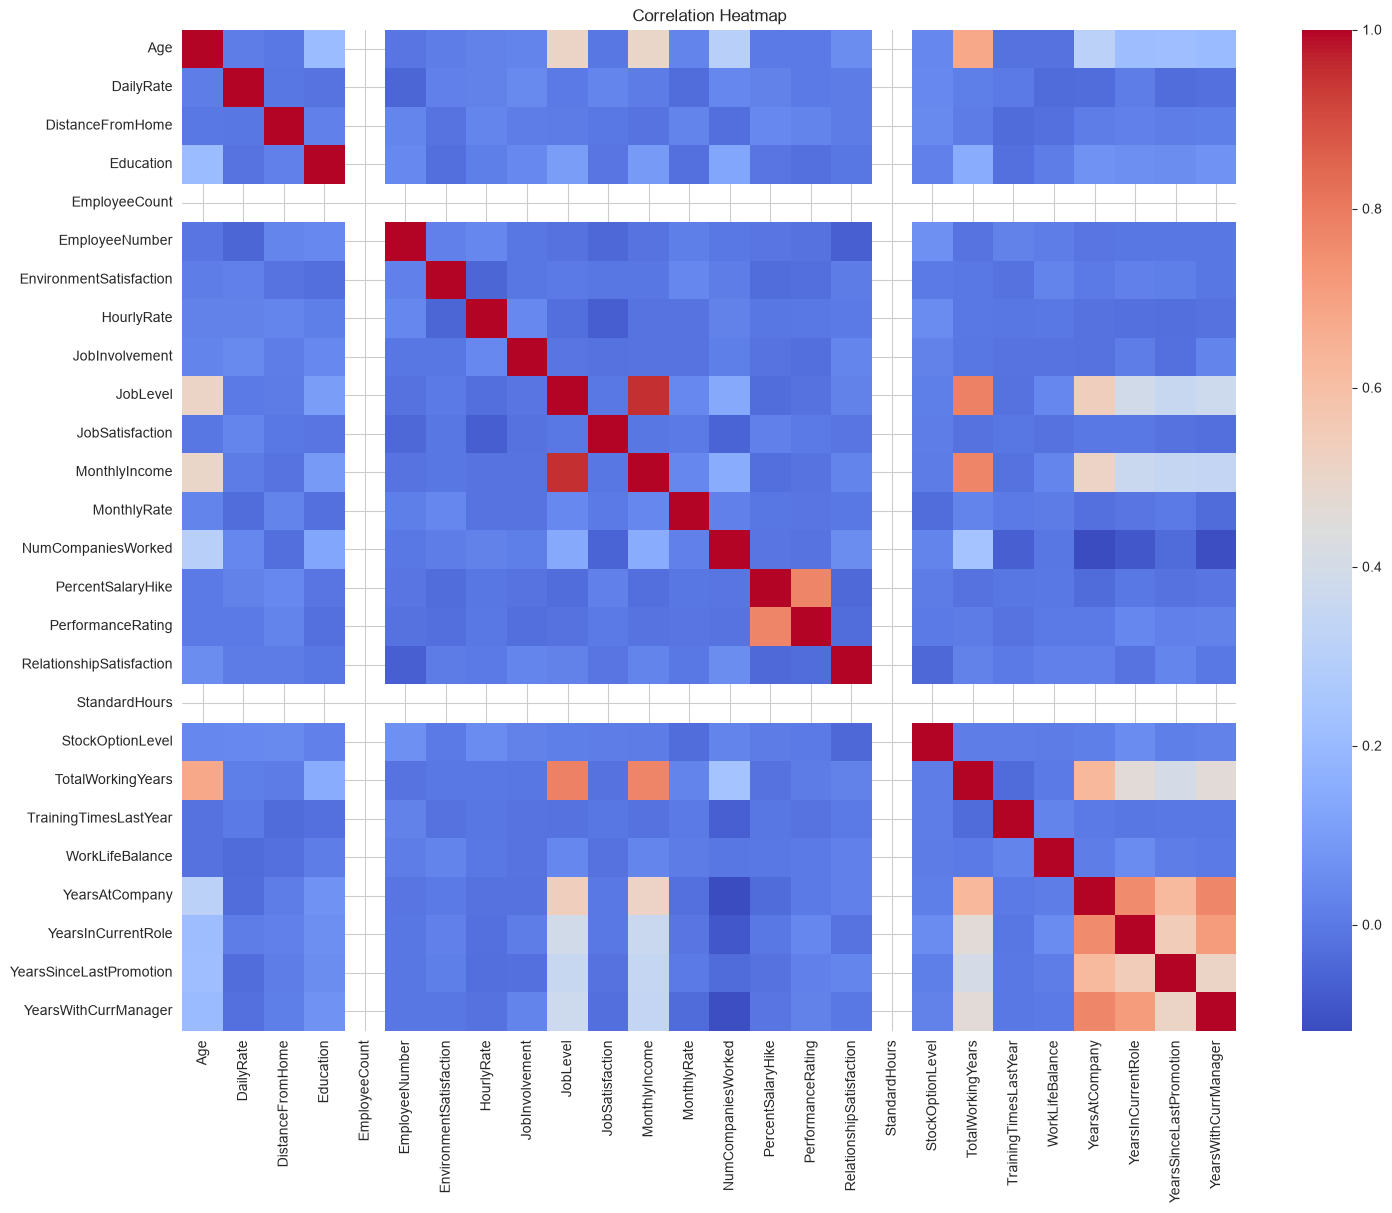

In [25]:
plt.figure(figsize=(17,13))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()


## Business Insights

1. The dataset is imbalanced, as employees who stayed significantly outnumber employees who left.

2. Employees working overtime show a higher attrition rate than employees who do not work overtime.

3. Employees with lower monthly income are more likely to leave the company.

4. The Sales department experiences higher attrition compared to other departments.

5. Job roles such as Sales Executive and Laboratory Technician have relatively higher attrition.

6. Younger employees show a higher tendency to leave the organization.

7. JobLevel and MonthlyIncome have a strong positive relationship, indicating that higher job levels receive higher salaries.

8. YearsAtCompany, YearsInCurrentRole, and YearsWithCurrManager are strongly correlated, suggesting that employees who stay longer in the company also remain longer in the same role and with the same manager.